In [1]:
import pandas as pd
import numpy as np

import joblib
from pathlib import Path

pd.set_option("display.max_columns", 120)

DATA_DIR = Path("../data")
MODEL_DIR = Path("../models")
OUT_DIR = Path("../data/processed")

OUT_DIR.mkdir(parents=True, exist_ok=True)


In [3]:
df = pd.read_csv(DATA_DIR / "raw/rental_report_final.csv")

print("Total NTAs:", len(df))
print("Missing rent:", df["median_monthly_rent"].isna().sum())
df.head()


Total NTAs: 260
Missing rent: 85


,nta2020,ntaname,num_bbls,avg_unitsres,avg_unitstotal,avg_yearbuilt,avg_market_value,num_properties,school_count,avg_ats,murder,rape,robbery,felony_assault,burglary,grand_larceny,grand_larceny_auto,total_violations,buildings_with_violations,violations_per_building,rent_impairing_violations,pct_rent_impairing,rent_num_properties,avg_monthly_rent,median_monthly_rent
0,QN8191,Flushing Meadows-Corona Park,31,0.000000,0.129032,442.806452,5.577701e+03,36.487311,NaN,NaN,0.595083,17.759920,185.886253,263.831372,92.675146,383.097319,118.814453,14.0,1.0,14.0000,0.0,0.0000,NaN,NaN,NaN
1,QN0601,Rego Park,2583,5.470770,5.953930,1906.347658,7.774261e+05,4704.243264,NaN,NaN,0.225370,3.490564,20.929933,34.290739,32.218593,89.470923,34.229803,10802.0,323.0,33.4427,610.0,0.0565,28.0,1902.657064,1869.060588
2,BK1204,Mapleton-Midwood (West),5143,2.547540,2.723702,1904.803228,8.090730e+05,6279.703180,NaN,NaN,0.976761,4.217520,32.988229,64.446533,41.426248,147.547358,66.761663,26663.0,933.0,28.5777,1366.0,0.0512,13.0,3324.565056,2444.750000
3,BX0702,Bedford Park,1309,17.839572,18.310924,1835.779985,1.097847e+06,1385.907912,NaN,NaN,2.108588,11.711685,117.391944,206.040030,55.494601,238.921371,89.940230,143154.0,847.0,169.0130,9345.0,0.0653,6.0,1946.530777,1529.090556
4,BK1771,Holy Cross Cemetery,1,0.000000,0.000000,1917.000000,8.039164e+01,1.038566,NaN,NaN,0.364676,2.051302,11.259369,36.649930,7.794948,27.760955,8.205208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
model = joblib.load(MODEL_DIR / "03_final_model.joblib")
model


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 HistGradientBoostingRegressor(learning_rate=0.05, max_depth=6,
                                               min_samples_leaf=10,
                                               random_state=42))])

In [5]:
TARGET = "log_median_rent"

EXCLUDE_COLS = [
    "nta2020",
    "ntaname",
    "median_monthly_rent",
    "avg_monthly_rent",
    "rent_num_properties",
    TARGET
]

feature_cols = [c for c in df.columns if c not in EXCLUDE_COLS]

X = df[feature_cols].apply(pd.to_numeric, errors="coerce")

# Drop all-NaN columns (safety, should match File 03)
all_nan_cols = X.columns[X.isna().all()].tolist()
if all_nan_cols:
    print("Dropping all-NaN columns:", all_nan_cols)
    X = X.drop(columns=all_nan_cols)

feature_cols = X.columns.tolist()
print("Using", len(feature_cols), "features")


Dropping all-NaN columns: ['school_count', 'avg_ats']
Using 18 features


In [6]:
df["pred_log_median_rent"] = model.predict(X)
df["pred_median_rent"] = np.exp(df["pred_log_median_rent"])


In [7]:
final_output = df[[
    "nta2020",
    "ntaname",
    "median_monthly_rent",
    "pred_median_rent"
]].copy()

final_output["rent_source"] = np.where(
    final_output["median_monthly_rent"].notna(),
    "actual",
    "predicted"
)

final_output.sort_values("pred_median_rent", ascending=False).head(10)


,nta2020,ntaname,median_monthly_rent,pred_median_rent,rent_source
70,MN0102,Tribeca-Civic Center,8318.054167,6169.064164,actual
258,MN0501,Midtown South-Flatiron-Union Square,6582.995370,5918.995101,actual
248,MN0802,Upper East Side-Carnegie Hill,6688.144330,5726.878189,actual
129,MN0401,Chelsea-Hudson Yards,6789.289338,5692.941765,actual
243,MN0101,Financial District-Battery Park City,5062.363095,5670.333567,actual
208,MN0502,Midtown-Times Square,4948.192857,5248.972533,actual
249,MN0803,Upper East Side-Yorkville,4566.346995,5216.211653,actual
197,MN0603,Murray Hill-Kips Bay,4343.526496,5134.867491,actual
253,MN0604,East Midtown-Turtle Bay,4661.069135,4832.767169,actual
190,MN0801,Upper East Side-Lenox Hill-Roosevelt Island,4282.465884,4808.917547,actual


In [8]:
# Count check
print(final_output["rent_source"].value_counts())

# Are predictions reasonable?
print(final_output["pred_median_rent"].describe())


rent_source
actual       175
predicted     85
Name: count, dtype: int64
count     260.000000
mean     2191.486846
std       918.511533
min       968.561501
25%      1700.930964
50%      1894.299875
75%      2310.105637
max      6169.064164
Name: pred_median_rent, dtype: float64


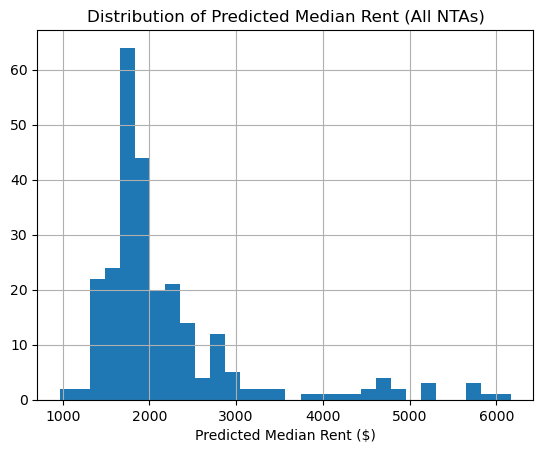

In [9]:
import matplotlib.pyplot as plt

final_output["pred_median_rent"].hist(bins=30)
plt.title("Distribution of Predicted Median Rent (All NTAs)")
plt.xlabel("Predicted Median Rent ($)")
plt.show()


In [10]:
final_output.to_csv(OUT_DIR / "04_final_nta_rent_predictions.csv", index=False)

print("Saved:",
      OUT_DIR / "04_final_nta_rent_predictions.csv")


Saved: ../data/processed/04_final_nta_rent_predictions.csv
